In [1]:
import os
import os.path
import fnmatch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from itertools import chain
from scipy.fftpack import fft, ifft

In [3]:
if not os.path.exists("Results"): os.mkdir("Results")
if not os.path.exists("Results/Networkx"): os.mkdir("Results/Networkx")
if not os.path.exists("Results/Networkx/output_csv"): os.mkdir("Results/Networkx/output_csv")
if not os.path.exists("Results/Networkx/output_csv/sociality_linked_neurons"): os.mkdir("Results/Networkx/output_csv/sociality_linked_neurons")

if not os.path.exists("Results/Networkx/figure"): os.mkdir("Results/Networkx/figure")
if not os.path.exists("Results/Networkx/figure/sociality_linked_neurons"): os.mkdir("Results/Networkx/figure/sociality_linked_neurons")
    
savecsv = "Results/Networkx/output_csv/sociality_linked_neurons/" 
savefig = "Results/Networkx/figure/sociality_linked_neurons/"

In [15]:
#Genotype of each number
# WT_Number = ["NO.1", "NO.2", "NO.8", "NO.15"]
# Tbr1_Number = ["NO.3", "NO.13", "NO.16", "NO.20"]

WT_Number = ["NO.1"]
Tbr1_Number = ["NO.3"]

#Treatment and behavior
drinks = ["Water", "Cocktail"]
behaviors = ["OE", "RSI"]

In [5]:
def Cosine_similarity (number, drink, behavior, savecsv):
    
    #read csv file
    fdir1 = "./Calcium_imaging_data/" + drink + "/" + number + "/"+ behavior
    z_score_activity = pd.read_csv(fdir1+ "/output_files/accrawt_z.csv", index_col=0, header=0).values

    #generate cosine similarity of shuffled social interaction and calcium signal
    np.random.seed(17)
    shuffletimes = 10000   #shuffled 10000times

    cs_cell_all = []
    cs_p_all = []
    
    for i in np.arange(len(z_score_activity)):
        cs_cell = []
        cs_p_cell = []

        for j in np.arange(len(z_score_activity)):
            cs_raw_ind = []
            cs_shuffle_ind = []
            cs_p1 = 0
            
            if i >= j:
                rowr1 = z_score_activity[i,:]
                rowr2= z_score_activity[j,:]

                #Cosine  similarity (Raw data)
                cs_raw = cosine_similarity([rowr1], [rowr2]).tolist()
                cs_raw2 = list(chain(*cs_raw))

                for a in tqdm(range (shuffletimes)):

                    #Fourier transformation
                    trace_fft = fft(rowr2)    #FFT
                    amp = np.abs(trace_fft)    #Amplitude
                    phase = np.angle(trace_fft)    #Phase
        #             sample_rate = 10
        #             freq = np.fft.fftfreq(z_score_activity.size, d = 1 / sample_rate)      #Frequency

                    #Phase randomization
                    ph_noise = np.random.permutation(phase)
        #             trace_random =  ifft(amp * np.exp(1j * ph_noise))
                    trace_random =  np.round(np.abs(ifft(amp * np.exp(1j*ph_noise))))    #https://github.com/JackEdTaylor/randphase

                    #Cosine  similarity (Shuffled data)
                    cs_shuffle = cosine_similarity([rowr1], [trace_random]).tolist()
                    cs_shuffle2 = list(chain(*cs_shuffle))

                    for k in cs_shuffle2:
                        cs_shuffle_ind.append(k)

                        if k >= cs_raw2[0]:
                            cs_p1 += 1

                cs_p =  cs_p1/shuffletimes
                cs_p_cell.append(cs_p)

                cs_cell.append(cs_raw2[0])
                
            else:
                cs_p_cell.append(np.nan)
                cs_cell.append(np.nan)

        cs_cell_all.append(cs_cell)
        cs_p_all.append(cs_p_cell)
        
    #save as CSV files
    pd.DataFrame(cs_cell_all).to_csv(savecsv + "cosine_similarity.csv")

    #save as CSV files
    pd.DataFrame(cs_p_all).to_csv(savecsv + "cosine_similarity_p.csv")

In [53]:
# def Sub_network_centrality(nm, dk, bh, savecsv, savefig):
#     #read txt file
#     Parsing_cells = pd.read_table("parsing_cell_type_to_links_"+ nm +".txt", index_col=0)
#     #read Multi-session registration file
#     MSR = pd.read_csv("Multi-session_registration_"+ nm +".csv", index_col=0, header=0)

#     #read P_value of Cosine similarity files
#     CS_p_table = pd.read_csv(savecsv + "cosine_similarity_p.csv", index_col=0)
#     CS_p_table.index = CS_p_table.index+1
#     CS_p_table.columns = CS_p_table.index
    
#     #calculate the subset centrality
#     cell_type = []
    
#     social_connection_number = []
#     non_social_connection_number = []
    
#     social_connection_centrality = []
#     non_social_connection_centrality = []
    
    
#     if dk =="Water":
#         col = "Water_RSI"
        
#     elif dk =="Cocktail":
#         col = "Cocktail_RSI"
    
#     for i in CS_p_table.index:
#         for k in range(len(MSR)):
#             if MSR.loc[k][dk + "_" + bh] == i:
#                 if Parsing_cells.loc[k][col] == "activation":
#                     cell_type.append("activation")
#                 elif Parsing_cells.loc[k][col] == "inhibition":
#                     cell_type.append("inhibition")
#                 else:
#                     cell_type.append("other")
        
        
#         #calculate the number of each subset connection
#         social_connection = 0
#         non_social_connection = 0
#         for j in CS_p_table.columns:
#             if i != j:
#                 if CS_p_table.loc[i][j] <= 0.0083:
#                     for k in range(len(MSR)):
#                         if MSR.loc[k][dk + "_" + bh] == j:
#                             if Parsing_cells.loc[k][col] == "activation":
#                                 social_connection += 1
#                             elif Parsing_cells.loc[k][col] == "inhibition":
#                                 social_connection += 1
#                             else:
#                                 non_social_connection += 1
            
#         if (social_connection+non_social_connection) != 0:
#             social_connection_ratio = (social_connection/(social_connection+non_social_connection))**2
#             non_social_connection_ratio = (non_social_connection/(social_connection+non_social_connection))**2

#             social_connection_number.append(social_connection)
#             non_social_connection_number.append(non_social_connection)

#             social_connection_centrality.append(social_connection_ratio)
#             non_social_connection_centrality.append(non_social_connection_ratio)

#         else:
#             social_connection_number.append(social_connection)
#             non_social_connection_number.append(non_social_connection)

#             social_connection_centrality.append(0)
#             non_social_connection_centrality.append(0)
            
            
#     df = pd.DataFrame (list (zip(cell_type, social_connection_number, non_social_connection_number, social_connection_centrality, non_social_connection_centrality)), 
#                       columns = ["cell_type", "social_connection_number", "non_social_connection_number", "social_connection_centrality", "non_social_connection_centrality", ])
#     #save to csv file
#     df.to_csv(savecsv + '/subset_centrality.csv')

In [9]:
def Sub_network_centrality(nm, dk, bh, savecsv, savefig):
    #read txt file
    Parsing_cells = pd.read_table("parsing_cell_type_to_links_"+ nm +".txt", index_col=0)
    #read Multi-session registration file
    MSR = pd.read_csv("./Calcium_imaging_data/Multi-session_registration_"+ nm +".csv", index_col=0, header=0)

    #read P_value of Cosine similarity files
    CS_p_table = pd.read_csv(savecsv + "cosine_similarity_p.csv", index_col=0)
    CS_p_table.index = CS_p_table.index+1
    CS_p_table.columns = CS_p_table.index
    
    #calculate the subset centrality
    cell_type = []
    
    social_connection_number = []
    non_social_connection_number = []
    
    
    if dk =="Water":
        col = "Water_RSI"
        
    elif dk =="Cocktail":
        col = "Cocktail_RSI"
    
    for i in CS_p_table.index:
        for k in range(len(MSR)):
            if MSR.loc[k][dk + "_" + bh] == i:
                if Parsing_cells.loc[k][col] == "activation":
                    cell_type.append("activation")
                elif Parsing_cells.loc[k][col] == "inhibition":
                    cell_type.append("inhibition")
                else:
                    cell_type.append("other")
        

        #calculate the number of each subset connection
        social_connection = 0
        non_social_connection = 0
        for j in CS_p_table.columns:
            if i != j:
                if CS_p_table.loc[i][j] <= 0.0083:
                    for k in range(len(MSR)):
                        if MSR.loc[k][dk + "_" + bh] == j:
                            if Parsing_cells.loc[k][col] == "activation":
                                social_connection += 1
                            elif Parsing_cells.loc[k][col] == "inhibition":
                                social_connection += 1
                            else:
                                non_social_connection += 1
            
        social_connection_number.append(social_connection)
        non_social_connection_number.append(non_social_connection)
            
    all_connection_number = sum(social_connection_number+non_social_connection_number)
    social_connection_centrality = (np.array(social_connection_number)/all_connection_number)**2
    non_social_connection_centrality = (np.array(non_social_connection_number)/all_connection_number)**2
    
    
    df = pd.DataFrame (list (zip(cell_type, social_connection_number, non_social_connection_number, social_connection_centrality, non_social_connection_centrality)), 
                      columns = ["cell_type", "social_connection_number", "non_social_connection_number", "social_connection_centrality", "non_social_connection_centrality", ])
    #save to csv file
    df.to_csv(savecsv + '/Centrality_subset.csv')

In [7]:
def Networkx_function(nm, dk, bh, savecsv, savefig):    
    #read txt file
    Parsing_cells = pd.read_table("parsing_cell_type_to_links_"+ nm +".txt", index_col=0)
    #read Multi-session registration file
    MSR = pd.read_csv("./Calcium_imaging_data/Multi-session_registration_"+ nm +".csv", index_col=0, header=0)


    #read Cosine similarity and P_value files
    CS_table = pd.read_csv(savecsv + "cosine_similarity.csv", index_col=0)
    CS_table.index = CS_table.index+1
    CS_table.columns = CS_table.index

    CS_p_table = pd.read_csv(savecsv + "cosine_similarity_p.csv", index_col=0)
    CS_p_table.index = CS_p_table.index+1
    CS_p_table.columns = CS_p_table.index


    #draw heatmap and networks
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    sns.heatmap(CS_table)
    plt.title("Cosine Similarity")

    plt.subplot(1,3,2)
    sns.heatmap(CS_p_table, cmap="Greys")
    plt.title("Cosine Similarity_p")

    plt.subplot(1,3,3)
    G = nx.Graph()
    colors = []
    cell_type = []

    if dk =="Water":
        col = "Water_RSI"
        
    elif dk =="Cocktail":
        col = "Cocktail_RSI"
    
    for i in CS_table.index:
        G.add_node(i)

        #define color
        for k in range(len(MSR)):
            if MSR.loc[k][dk + "_" + bh] == i:

                if Parsing_cells.loc[k][col] == "activation":
                    colors.append("red")
                    cell_type.append("activation")
                elif Parsing_cells.loc[k][col] == "inhibition":
                    colors.append("lightblue")
                    cell_type.append("inhibition")
                else:
                    colors.append("gray")
                    cell_type.append("other")

        for j in CS_table.columns:
            if i != j:
                if CS_p_table.loc[i][j] <= 0.0083:
                    w = CS_table.loc[i][j]
                    G.add_edge(i,j, weight= w)
        #             G.add_edge(i,j, weight= round(w,1))

    pos = nx.spring_layout(G, scale=1, seed=17)
    # weight= nx.get_edge_attributes(G, "weight")

    nx.draw_networkx(G, pos, with_labels=True, font_weight='bold', 
                     node_size=40, font_size=5, alpha=1, node_color=colors,
                     edge_color='orange')
    plt.title("Networks")
    plt.box(False)
    
    plt.tight_layout()

    plt.savefig(savefig + "Networkx_2.pdf", transparent=True, bbox_inches="tight")
    plt.savefig(savefig + "Networkx_2.tif", transparent=True, bbox_inches="tight", dpi=720)
    
    
    #Degree_centrality
    DC = pd.DataFrame.from_dict(nx.degree_centrality(G), orient='index', columns=["Degree_centrality"])
    #Eigenvector_centrality
    EC = pd.DataFrame.from_dict(nx.eigenvector_centrality(G, max_iter=1000), orient='index', columns =["Eigenvector_centrality"])
    All_centrality = pd.concat([DC,EC], axis=1)
    All_centrality["Cell_type"] = cell_type
    
    #save as CSV files
    pd.DataFrame(All_centrality).to_csv(savecsv + "Centrality_all.csv")
    
    G.clear()

100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:17<00:00, 575.42it/s]


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:18<00:00, 544.54it/s]


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:18<00:00, 544.19it/s]


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:18<00:00, 543.37it/s]


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:19<00:00, 516.24it/s]


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:13<00:00, 726.86it/s]


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:13<00:00, 718.55it/s]


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:13<00:00, 729.86it/s]


    Degree_centrality  Eigenvector_centrality   Cell_type Genotype     Drink  \
0            0.000000            5.362076e-10       other       WT     Water   
1            0.071429            4.202449e-02       other       WT     Water   
2            0.571429            3.045936e-01       other       WT     Water   
3            0.500000            2.650493e-01       other       WT     Water   
4            0.142857            6.923180e-02       other       WT     Water   
..                ...                     ...         ...      ...       ...   
56           0.600000            2.258416e-01       other       WT  Cocktail   
57           0.800000            3.063924e-01  activation       WT  Cocktail   
58           0.666667            2.416523e-01  activation       WT  Cocktail   
59           0.133333            4.426673e-02       other       WT  Cocktail   
60           0.000000            7.337550e-11       other       WT  Cocktail   

   Behavior Number  
0        OE   NO.1

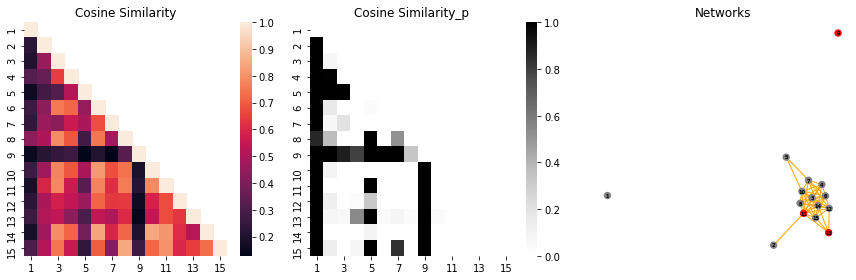

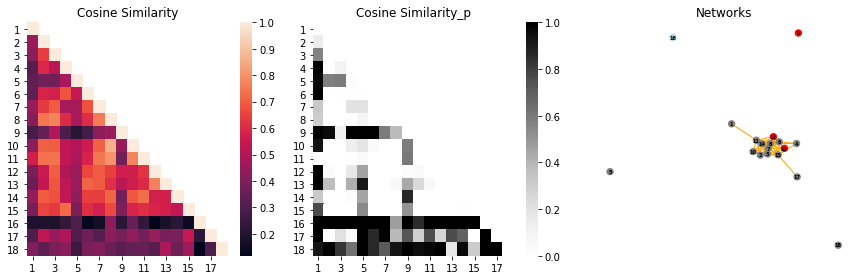

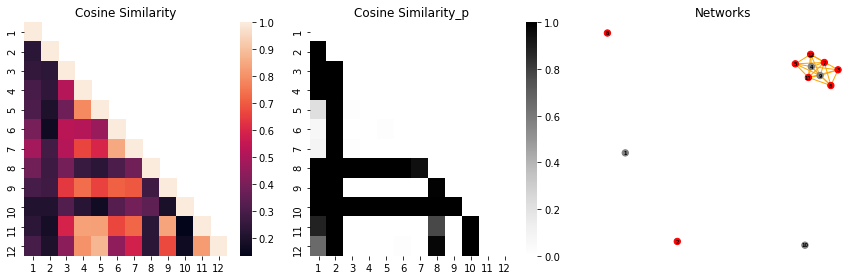

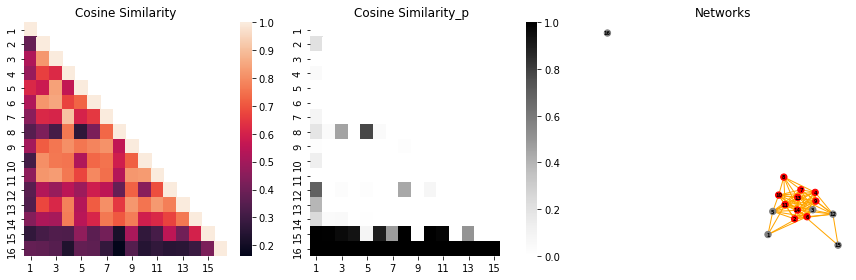

In [16]:
if not os.path.exists(savecsv + "WT"): os.mkdir(savecsv + "WT")
if not os.path.exists(savefig + "WT"): os.mkdir(savefig + "WT")
    
WT_Centrality = pd.DataFrame([])
WT_Subset_Centrality = pd.DataFrame([])

for nm in WT_Number:
    
    if not os.path.exists(savecsv + "WT/" + nm): os.mkdir(savecsv + "WT/" + nm)
    if not os.path.exists(savefig + "WT/" + nm): os.mkdir(savefig + "WT/" + nm)
    
    #read txt file
    Parsing_cells = pd.read_table("parsing_cell_type_to_links_"+ nm +".txt")
    #read Multi-session registration file
    MSR = pd.read_csv("./Calcium_imaging_data/Multi-session_registration_"+ nm +".csv", index_col=0, header=0)
    
    for dk in drinks:
        
        if not os.path.exists(savecsv + "WT/" + nm + "/" + dk): os.mkdir(savecsv + "WT/" + nm + "/" + dk)
        if not os.path.exists(savefig + "WT/" + nm + "/" + dk): os.mkdir(savefig + "WT/" + nm + "/" + dk)
            
        for bh in behaviors:
            
            if not os.path.exists(savecsv + "WT/" + nm + "/" + dk + "/" + bh): os.mkdir(savecsv + "WT/" + nm + "/" + dk + "/" + bh)
            if not os.path.exists(savefig + "WT/" + nm + "/" + dk + "/" + bh): os.mkdir(savefig + "WT/" + nm + "/" + dk + "/" + bh)
        
            savecsv1 = savecsv + "WT/" + nm + "/" + dk + "/" + bh + "/"
            savefig1 = savefig + "WT/" + nm + "/" + dk + "/" + bh + "/"

            
            Cosine_similarity(nm, dk, bh, savecsv1)
            
            Networkx_function(nm, dk, bh, savecsv1, savefig1)
        
            Sub_network_centrality(nm, dk, bh, savecsv1, savefig1)


            #read Centrality file
            Centrality = pd.read_csv(savecsv1+ "Centrality_all.csv", index_col=0, header=0)
            Centrality["Genotype"] = "WT"
            Centrality["Drink"] = dk
            Centrality["Behavior"] = bh
            Centrality["Number"] = nm
            
            WT_Centrality = WT_Centrality.append(Centrality, ignore_index=True)
            
            #read subset centrality file
            subset_centrality = pd.read_csv(savecsv1+ "Centrality_subset.csv", index_col=0, header=0)
            subset_centrality["Genotype"] = "WT"
            subset_centrality["Drink"] = dk
            subset_centrality["Behavior"] = bh
            subset_centrality["Number"] = nm
            
            WT_Subset_Centrality = WT_Subset_Centrality.append(subset_centrality, ignore_index=True)
            
print(WT_Centrality)
print(WT_Subset_Centrality)

100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:14<00:00, 711.07it/s]


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:13<00:00, 745.82it/s]


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:13<00:00, 735.26it/s]


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:13<00:00, 732.09it/s]


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:13<00:00, 732.31it/s]


...

100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:13<00:00, 740.51it/s]


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:13<00:00, 768.91it/s]


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:13<00:00, 757.38it/s]


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:13<00:00, 757.14it/s]


     Degree_centrality  Eigenvector_centrality   Cell_type Genotype     Drink  \
0             0.046512            1.023091e-01       other     Tbr1     Water   
1             0.116279            2.281718e-01       other     Tbr1     Water   
2             0.162791            2.828241e-01       other     Tbr1     Water   
3             0.069767            5.641669e-03       other     Tbr1     Water   
4             0.232558            2.759187e-01       other     Tbr1     Water   
..                 ...                     ...         ...      ...       ...   
99            0.363636            3.692618e-01       other     Tbr1  Cocktail   
100           0.272727            2.741618e-01  activation     Tbr1  Cocktail   
101           0.272727            2.741618e-01  activation     Tbr1  Cocktail   
102           0.000000            6.258003e-10       other     Tbr1  Cocktail   
103           0.181818            1.965953e-01       other     Tbr1  Cocktail   

    Behavior Number  
0    

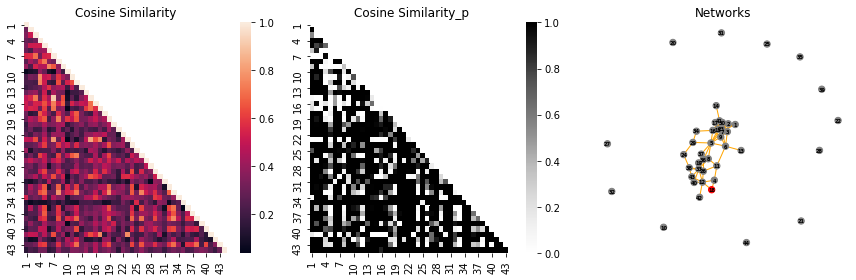

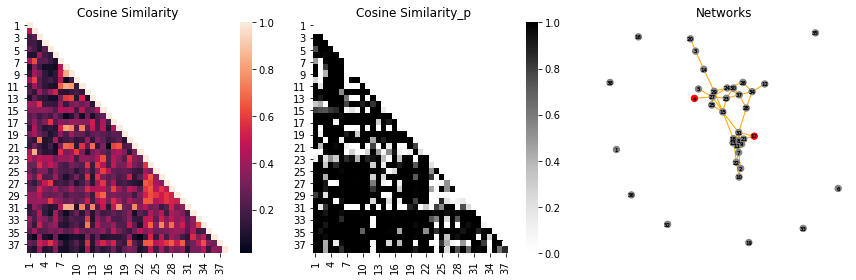

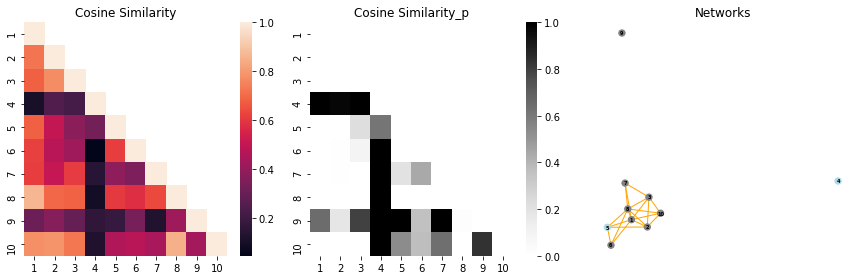

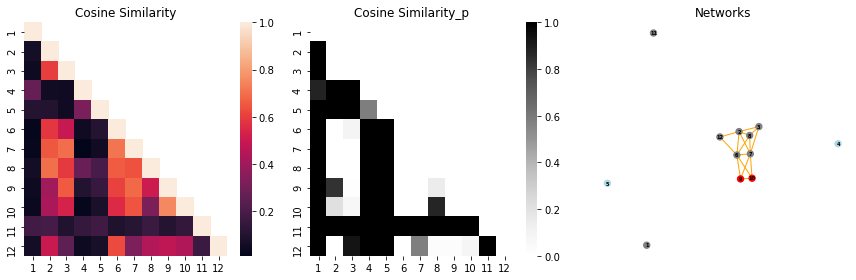

In [13]:
if not os.path.exists(savecsv + "Tbr1"): os.mkdir(savecsv + "Tbr1")
if not os.path.exists(savefig + "Tbr1"): os.mkdir(savefig + "Tbr1")
    
Tbr1_Centrality = pd.DataFrame([])
Tbr1_Subset_Centrality = pd.DataFrame([])

for nm in Tbr1_Number:
    
    if not os.path.exists(savecsv + "Tbr1/" + nm): os.mkdir(savecsv + "Tbr1/" + nm)
    if not os.path.exists(savefig + "Tbr1/" + nm): os.mkdir(savefig + "Tbr1/" + nm)
    
    #read txt file
    Parsing_cells = pd.read_table("parsing_cell_type_to_links_"+ nm +".txt")
    #read Multi-session registration file
    MSR = pd.read_csv("./Calcium_imaging_data/Multi-session_registration_"+ nm +".csv", index_col=0, header=0)
    
    for dk in drinks:
        
        if not os.path.exists(savecsv + "Tbr1/" + nm + "/" + dk): os.mkdir(savecsv + "Tbr1/" + nm + "/" + dk)
        if not os.path.exists(savefig + "Tbr1/" + nm + "/" + dk): os.mkdir(savefig + "Tbr1/" + nm + "/" + dk)
            
        for bh in behaviors:
            
            if not os.path.exists(savecsv + "Tbr1/" + nm + "/" + dk + "/" + bh): os.mkdir(savecsv + "Tbr1/" + nm + "/" + dk + "/" + bh)
            if not os.path.exists(savefig + "Tbr1/" + nm + "/" + dk + "/" + bh): os.mkdir(savefig + "Tbr1/" + nm + "/" + dk + "/" + bh)
        
            savecsv1 = savecsv + "Tbr1/" + nm + "/" + dk + "/" + bh + "/"
            savefig1 = savefig + "Tbr1/" + nm + "/" + dk + "/" + bh + "/"

            
            Cosine_similarity(nm, dk, bh, savecsv1)
            
            Networkx_function(nm, dk, bh, savecsv1, savefig1)

            Sub_network_centrality(nm, dk, bh, savecsv1, savefig1)


            #read Centrality file
            Centrality = pd.read_csv(savecsv1+ "Centrality_all.csv", index_col=0, header=0)
            Centrality["Genotype"] = "Tbr1"
            Centrality["Drink"] = dk
            Centrality["Behavior"] = bh
            Centrality["Number"] = nm
            
            Tbr1_Centrality = Tbr1_Centrality.append(Centrality, ignore_index=True)
            
            #read subset centrality file
            subset_centrality = pd.read_csv(savecsv1+ "Centrality_subset.csv", index_col=0, header=0)
            subset_centrality["Genotype"] = "Tbr1"
            subset_centrality["Drink"] = dk
            subset_centrality["Behavior"] = bh
            subset_centrality["Number"] = nm
            
            Tbr1_Subset_Centrality = Tbr1_Subset_Centrality.append(subset_centrality, ignore_index=True)

print(Tbr1_Centrality)
print(Tbr1_Subset_Centrality)

In [29]:
#separate different group
WT_Water_OE_cells = WT_Centrality[(WT_Centrality["Genotype"]=="WT") & 
                                  (WT_Centrality["Drink"]=="Water") & 
                                  (WT_Centrality["Behavior"]=="OE")]

WT_Water_RSI_cells = WT_Centrality[(WT_Centrality["Genotype"]=="WT") & 
                                   (WT_Centrality["Drink"]=="Water") & 
                                   (WT_Centrality["Behavior"]=="RSI")]

WT_Cocktail_OE_cells = WT_Centrality[(WT_Centrality["Genotype"]=="WT") & 
                                     (WT_Centrality["Drink"]=="Cocktail") & 
                                     (WT_Centrality["Behavior"]=="OE")]

WT_Cocktail_RSI_cells = WT_Centrality[(WT_Centrality["Genotype"]=="WT") & 
                                      (WT_Centrality["Drink"]=="Cocktail") & 
                                      (WT_Centrality["Behavior"]=="RSI")]


Tbr1_Water_OE_cells = Tbr1_Centrality[(Tbr1_Centrality["Genotype"]=="Tbr1") & 
                                      (Tbr1_Centrality["Drink"]=="Water") & 
                                      (Tbr1_Centrality["Behavior"]=="OE")]

Tbr1_Water_RSI_cells = Tbr1_Centrality[(Tbr1_Centrality["Genotype"]=="Tbr1") & 
                                       (Tbr1_Centrality["Drink"]=="Water") & 
                                       (Tbr1_Centrality["Behavior"]=="RSI")]

Tbr1_Cocktail_OE_cells = Tbr1_Centrality[(Tbr1_Centrality["Genotype"]=="Tbr1") & 
                                         (Tbr1_Centrality["Drink"]=="Cocktail") & 
                                         (Tbr1_Centrality["Behavior"]=="OE")]

Tbr1_Cocktail_RSI_cells = Tbr1_Centrality[(Tbr1_Centrality["Genotype"]=="Tbr1") & 
                                          (Tbr1_Centrality["Drink"]=="Cocktail") & 
                                          (Tbr1_Centrality["Behavior"]=="RSI")]



#calculate mean (Degree_centrality)
WT_Water_OE_cells_mean_DC = WT_Water_OE_cells["Degree_centrality"].mean(axis=0)
WT_Water_OE_cells_mean_DC = WT_Water_OE_cells["Degree_centrality"].mean(axis=0)

WT_Water_RSI_cells_mean_DC = WT_Water_RSI_cells["Degree_centrality"].mean(axis=0)
WT_Water_RSI_cells_mean_DC = WT_Water_RSI_cells["Degree_centrality"].mean(axis=0)

WT_Cocktail_OE_cells_mean_DC = WT_Cocktail_OE_cells["Degree_centrality"].mean(axis=0)
WT_Cocktail_OE_cells_mean_DC = WT_Cocktail_OE_cells["Degree_centrality"].mean(axis=0)

WT_Cocktail_RSI_cells_mean_DC = WT_Cocktail_RSI_cells["Degree_centrality"].mean(axis=0)
WT_Cocktail_RSI_cells_mean_DC = WT_Cocktail_RSI_cells["Degree_centrality"].mean(axis=0)

Tbr1_Water_OE_cells_mean_DC = Tbr1_Water_OE_cells["Degree_centrality"].mean(axis=0)
Tbr1_Water_OE_cells_mean_DC = Tbr1_Water_OE_cells["Degree_centrality"].mean(axis=0)

Tbr1_Water_RSI_cells_mean_DC = Tbr1_Water_RSI_cells["Degree_centrality"].mean(axis=0)
Tbr1_Water_RSI_cells_mean_DC = Tbr1_Water_RSI_cells["Degree_centrality"].mean(axis=0)

Tbr1_Cocktail_OE_cells_mean_DC = Tbr1_Cocktail_OE_cells["Degree_centrality"].mean(axis=0)
Tbr1_Cocktail_OE_cells_mean_DC = Tbr1_Cocktail_OE_cells["Degree_centrality"].mean(axis=0)

Tbr1_Cocktail_RSI_cells_mean_DC = Tbr1_Cocktail_RSI_cells["Degree_centrality"].mean(axis=0)
Tbr1_Cocktail_RSI_cells_mean_DC = Tbr1_Cocktail_RSI_cells["Degree_centrality"].mean(axis=0)

#calculate sem (Degree_centrality)
WT_Water_OE_cells_sem_DC = WT_Water_OE_cells["Degree_centrality"].sem(axis=0)
WT_Water_OE_cells_sem_DC = WT_Water_OE_cells["Degree_centrality"].sem(axis=0)

WT_Water_RSI_cells_sem_DC = WT_Water_RSI_cells["Degree_centrality"].sem(axis=0)
WT_Water_RSI_cells_sem_DC = WT_Water_RSI_cells["Degree_centrality"].sem(axis=0)

WT_Cocktail_OE_cells_sem_DC = WT_Cocktail_OE_cells["Degree_centrality"].sem(axis=0)
WT_Cocktail_OE_cells_sem_DC = WT_Cocktail_OE_cells["Degree_centrality"].sem(axis=0)

WT_Cocktail_RSI_cells_sem_DC = WT_Cocktail_RSI_cells["Degree_centrality"].sem(axis=0)
WT_Cocktail_RSI_cells_sem_DC = WT_Cocktail_RSI_cells["Degree_centrality"].sem(axis=0)

Tbr1_Water_OE_cells_sem_DC = Tbr1_Water_OE_cells["Degree_centrality"].sem(axis=0)
Tbr1_Water_OE_cells_sem_DC = Tbr1_Water_OE_cells["Degree_centrality"].sem(axis=0)

Tbr1_Water_RSI_cells_sem_DC = Tbr1_Water_RSI_cells["Degree_centrality"].sem(axis=0)
Tbr1_Water_RSI_cells_sem_DC = Tbr1_Water_RSI_cells["Degree_centrality"].sem(axis=0)

Tbr1_Cocktail_OE_cells_sem_DC = Tbr1_Cocktail_OE_cells["Degree_centrality"].sem(axis=0)
Tbr1_Cocktail_OE_cells_sem_DC = Tbr1_Cocktail_OE_cells["Degree_centrality"].sem(axis=0)

Tbr1_Cocktail_RSI_cells_sem_DC = Tbr1_Cocktail_RSI_cells["Degree_centrality"].sem(axis=0)
Tbr1_Cocktail_RSI_cells_sem_DC = Tbr1_Cocktail_RSI_cells["Degree_centrality"].sem(axis=0)

All_centrality = WT_Centrality.append(Tbr1_Centrality, ignore_index=True)
pd.DataFrame(All_centrality).to_csv(savecsv + "All_centrality.csv")

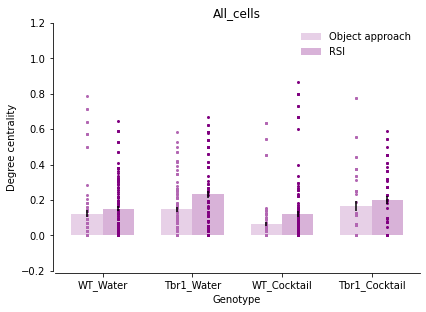

In [28]:
#draw bar plot
#draw social cells results
N = 4
ind = np.arange(N)    # the x locations for the groups
width = 0.35         # the width of the bars

plt.figure (figsize = (6,8))

ax1 = plt.subplot(2,1,1)
#OE
Water_OE_means_DC = [WT_Water_OE_cells_mean_DC, Tbr1_Water_OE_cells_mean_DC,
                     WT_Cocktail_OE_cells_mean_DC, Tbr1_Cocktail_OE_cells_mean_DC]

Water_OE_sem_DC = [WT_Water_OE_cells_sem_DC, Tbr1_Water_OE_cells_sem_DC,
                   WT_Cocktail_OE_cells_sem_DC, Tbr1_Cocktail_OE_cells_sem_DC]

ax1.bar(ind, Water_OE_means_DC, width, yerr=Water_OE_sem_DC, label='Object approach', color="#B266B2", alpha=0.3)

frames1= [WT_Water_OE_cells["Degree_centrality"], Tbr1_Water_OE_cells["Degree_centrality"], 
          WT_Cocktail_OE_cells["Degree_centrality"], Tbr1_Cocktail_OE_cells["Degree_centrality"]]
results1 = pd.concat(frames1)

ax1.scatter(([0]*len(WT_Water_OE_cells["Degree_centrality"])+
             [1]*len(Tbr1_Water_OE_cells["Degree_centrality"])+
             [2]*len(WT_Cocktail_OE_cells["Degree_centrality"])+
             [3]*len(Tbr1_Cocktail_OE_cells["Degree_centrality"])), 
            (results1), 
            s=4, c="#B266B2")

#RSI
Water_RSI_means_DC = [WT_Water_RSI_cells_mean_DC, Tbr1_Water_RSI_cells_mean_DC,
                        WT_Cocktail_RSI_cells_mean_DC, Tbr1_Cocktail_RSI_cells_mean_DC]

Water_RSI_sem_DC = [WT_Water_RSI_cells_sem_DC, Tbr1_Water_RSI_cells_sem_DC,
                      WT_Cocktail_RSI_cells_sem_DC, Tbr1_Cocktail_RSI_cells_sem_DC]

ax1.bar(ind + width, Water_RSI_means_DC, width, yerr=Water_RSI_sem_DC, label='RSI', color="purple", alpha=0.3)

frames2= [WT_Water_RSI_cells["Degree_centrality"], Tbr1_Water_RSI_cells["Degree_centrality"], 
          WT_Cocktail_RSI_cells["Degree_centrality"], Tbr1_Cocktail_RSI_cells["Degree_centrality"]]
results2 = pd.concat(frames2)

ax1.scatter(([width]*len(WT_Water_RSI_cells["Degree_centrality"])+
             [1+width]*len(Tbr1_Water_RSI_cells["Degree_centrality"])+
             [2+width]*len(WT_Cocktail_RSI_cells["Degree_centrality"])+
             [3+width]*len(Tbr1_Cocktail_RSI_cells["Degree_centrality"])), 
            (results2), 
            s=4, c="purple")

ax1.set_xticks([])
ax1.set(ylim=(-.2, 1.2))
plt.xticks(ind+width/2,['WT_Water','Tbr1_Water', 'WT_Cocktail','Tbr1_Cocktail'], rotation=0)

ax1.set_title("All_cells")
plt.xlabel ("Genotype")
plt.ylabel ("Degree centrality")

ax1.legend(frameon=False)

plt.tight_layout()
sns.despine(offset=2)


# plt.savefig(savefig + "Degree_centrality.pdf", transparent= True, bbox_inches="tight")
# plt.savefig(savefig + "Degree_centrality.tif", transparent= True, bbox_inches="tight", dpi=720)

In [8]:
#separate different group (WT)
WT_Water_OE_socialcells = WT_Centrality[(WT_Centrality["Genotype"]=="WT") & 
                                        (WT_Centrality["Drink"]=="Water") & 
                                        (WT_Centrality["Behavior"]=="OE") & 
                                        (WT_Centrality["Cell_type"].isin(["activation", "inhibition"]))]

WT_Water_OE_othercells = WT_Centrality[(WT_Centrality["Genotype"]=="WT") & 
                                       (WT_Centrality["Drink"]=="Water") & 
                                       (WT_Centrality["Behavior"]=="OE") & 
                                       (WT_Centrality["Cell_type"]=="other")]


WT_Water_RSI_socialcells = WT_Centrality[(WT_Centrality["Genotype"]=="WT") & 
                                         (WT_Centrality["Drink"]=="Water") & 
                                         (WT_Centrality["Behavior"]=="RSI") & 
                                         (WT_Centrality["Cell_type"].isin(["activation", "inhibition"]))]


WT_Water_RSI_othercells = WT_Centrality[(WT_Centrality["Genotype"]=="WT") & 
                                        (WT_Centrality["Drink"]=="Water") & 
                                        (WT_Centrality["Behavior"]=="RSI") & 
                                        (WT_Centrality["Cell_type"]=="other")]



#separate different group (Tbr1)
Tbr1_Water_OE_socialcells = Tbr1_Centrality[(Tbr1_Centrality["Genotype"]=="Tbr1") & 
                                            (Tbr1_Centrality["Drink"]=="Water") & 
                                            (Tbr1_Centrality["Behavior"]=="OE") & 
                                            (Tbr1_Centrality["Cell_type"].isin(["activation", "inhibition"]))]

Tbr1_Water_OE_othercells = Tbr1_Centrality[(Tbr1_Centrality["Genotype"]=="Tbr1") & 
                                           (Tbr1_Centrality["Drink"]=="Water") & 
                                           (Tbr1_Centrality["Behavior"]=="OE") & 
                                           (Tbr1_Centrality["Cell_type"]=="other")]


Tbr1_Water_RSI_socialcells = Tbr1_Centrality[(Tbr1_Centrality["Genotype"]=="Tbr1") & 
                                             (Tbr1_Centrality["Drink"]=="Water") & 
                                             (Tbr1_Centrality["Behavior"]=="RSI") & 
                                             (Tbr1_Centrality["Cell_type"].isin(["activation", "inhibition"]))]

Tbr1_Water_RSI_othercells = Tbr1_Centrality[(Tbr1_Centrality["Genotype"]=="Tbr1") & 
                                            (Tbr1_Centrality["Drink"]=="Water") & 
                                            (Tbr1_Centrality["Behavior"]=="RSI") & 
                                            (Tbr1_Centrality["Cell_type"]=="other")]




#calculate mean (Degree_centrality)
WT_Water_OE_socialcells_mean_DC = WT_Water_OE_socialcells["Degree_centrality"].mean(axis=0)
WT_Water_OE_othercells_mean_DC = WT_Water_OE_othercells["Degree_centrality"].mean(axis=0)

WT_Water_RSI_socialcells_mean_DC = WT_Water_RSI_socialcells["Degree_centrality"].mean(axis=0)
WT_Water_RSI_othercells_mean_DC = WT_Water_RSI_othercells["Degree_centrality"].mean(axis=0)

Tbr1_Water_OE_socialcells_mean_DC = Tbr1_Water_OE_socialcells["Degree_centrality"].mean(axis=0)
Tbr1_Water_OE_othercells_mean_DC = Tbr1_Water_OE_othercells["Degree_centrality"].mean(axis=0)

Tbr1_Water_RSI_socialcells_mean_DC = Tbr1_Water_RSI_socialcells["Degree_centrality"].mean(axis=0)
Tbr1_Water_RSI_othercells_mean_DC = Tbr1_Water_RSI_othercells["Degree_centrality"].mean(axis=0)

#calculate sem (Degree_centrality)
WT_Water_OE_socialcells_sem_DC = WT_Water_OE_socialcells["Degree_centrality"].sem(axis=0)
WT_Water_OE_othercells_sem_DC = WT_Water_OE_othercells["Degree_centrality"].sem(axis=0)

WT_Water_RSI_socialcells_sem_DC = WT_Water_RSI_socialcells["Degree_centrality"].sem(axis=0)
WT_Water_RSI_othercells_sem_DC = WT_Water_RSI_othercells["Degree_centrality"].sem(axis=0)

Tbr1_Water_OE_socialcells_sem_DC = Tbr1_Water_OE_socialcells["Degree_centrality"].sem(axis=0)
Tbr1_Water_OE_othercells_sem_DC = Tbr1_Water_OE_othercells["Degree_centrality"].sem(axis=0)

Tbr1_Water_RSI_socialcells_sem_DC = Tbr1_Water_RSI_socialcells["Degree_centrality"].sem(axis=0)
Tbr1_Water_RSI_othercells_sem_DC = Tbr1_Water_RSI_othercells["Degree_centrality"].sem(axis=0)


#calculate mean (Eigenvector_centrality)
WT_Water_OE_socialcells_mean_EC = WT_Water_OE_socialcells["Eigenvector_centrality"].mean(axis=0)
WT_Water_OE_othercells_mean_EC = WT_Water_OE_othercells["Eigenvector_centrality"].mean(axis=0)

WT_Water_RSI_socialcells_mean_EC = WT_Water_RSI_socialcells["Eigenvector_centrality"].mean(axis=0)
WT_Water_RSI_othercells_mean_EC = WT_Water_RSI_othercells["Eigenvector_centrality"].mean(axis=0)

Tbr1_Water_OE_socialcells_mean_EC = Tbr1_Water_OE_socialcells["Eigenvector_centrality"].mean(axis=0)
Tbr1_Water_OE_othercells_mean_EC = Tbr1_Water_OE_othercells["Eigenvector_centrality"].mean(axis=0)

Tbr1_Water_RSI_socialcells_mean_EC = Tbr1_Water_RSI_socialcells["Eigenvector_centrality"].mean(axis=0)
Tbr1_Water_RSI_othercells_mean_EC = Tbr1_Water_RSI_othercells["Eigenvector_centrality"].mean(axis=0)

#calculate sem (Eigenvector_centrality)
WT_Water_OE_socialcells_sem_EC = WT_Water_OE_socialcells["Eigenvector_centrality"].sem(axis=0)
WT_Water_OE_othercells_sem_EC = WT_Water_OE_othercells["Eigenvector_centrality"].sem(axis=0)

WT_Water_RSI_socialcells_sem_EC = WT_Water_RSI_socialcells["Eigenvector_centrality"].sem(axis=0)
WT_Water_RSI_othercells_sem_EC = WT_Water_RSI_othercells["Eigenvector_centrality"].sem(axis=0)

Tbr1_Water_OE_socialcells_sem_EC = Tbr1_Water_OE_socialcells["Eigenvector_centrality"].sem(axis=0)
Tbr1_Water_OE_othercells_sem_EC = Tbr1_Water_OE_othercells["Eigenvector_centrality"].sem(axis=0)

Tbr1_Water_RSI_socialcells_sem_EC = Tbr1_Water_RSI_socialcells["Eigenvector_centrality"].sem(axis=0)
Tbr1_Water_RSI_othercells_sem_EC = Tbr1_Water_RSI_othercells["Eigenvector_centrality"].sem(axis=0)

In [9]:
#separate different group (WT)
WT_Cocktail_OE_socialcells = WT_Centrality[(WT_Centrality["Genotype"]=="WT") & 
                                        (WT_Centrality["Drink"]=="Cocktail") & 
                                        (WT_Centrality["Behavior"]=="OE") & 
                                        (WT_Centrality["Cell_type"].isin(["activation", "inhibition"]))]

WT_Cocktail_OE_othercells = WT_Centrality[(WT_Centrality["Genotype"]=="WT") & 
                                       (WT_Centrality["Drink"]=="Cocktail") & 
                                       (WT_Centrality["Behavior"]=="OE") & 
                                       (WT_Centrality["Cell_type"]=="other")]


WT_Cocktail_RSI_socialcells = WT_Centrality[(WT_Centrality["Genotype"]=="WT") & 
                                         (WT_Centrality["Drink"]=="Cocktail") & 
                                         (WT_Centrality["Behavior"]=="RSI") & 
                                         (WT_Centrality["Cell_type"].isin(["activation", "inhibition"]))]


WT_Cocktail_RSI_othercells = WT_Centrality[(WT_Centrality["Genotype"]=="WT") & 
                                        (WT_Centrality["Drink"]=="Cocktail") & 
                                        (WT_Centrality["Behavior"]=="RSI") & 
                                        (WT_Centrality["Cell_type"]=="other")]



#separate different group (Tbr1)
Tbr1_Cocktail_OE_socialcells = Tbr1_Centrality[(Tbr1_Centrality["Genotype"]=="Tbr1") & 
                                            (Tbr1_Centrality["Drink"]=="Cocktail") & 
                                            (Tbr1_Centrality["Behavior"]=="OE") & 
                                            (Tbr1_Centrality["Cell_type"].isin(["activation", "inhibition"]))]

Tbr1_Cocktail_OE_othercells = Tbr1_Centrality[(Tbr1_Centrality["Genotype"]=="Tbr1") & 
                                           (Tbr1_Centrality["Drink"]=="Cocktail") & 
                                           (Tbr1_Centrality["Behavior"]=="OE") & 
                                           (Tbr1_Centrality["Cell_type"]=="other")]


Tbr1_Cocktail_RSI_socialcells = Tbr1_Centrality[(Tbr1_Centrality["Genotype"]=="Tbr1") & 
                                             (Tbr1_Centrality["Drink"]=="Cocktail") & 
                                             (Tbr1_Centrality["Behavior"]=="RSI") & 
                                             (Tbr1_Centrality["Cell_type"].isin(["activation", "inhibition"]))]

Tbr1_Cocktail_RSI_othercells = Tbr1_Centrality[(Tbr1_Centrality["Genotype"]=="Tbr1") & 
                                            (Tbr1_Centrality["Drink"]=="Cocktail") & 
                                            (Tbr1_Centrality["Behavior"]=="RSI") & 
                                            (Tbr1_Centrality["Cell_type"]=="other")]




#calculate mean (Degree_centrality)
WT_Cocktail_OE_socialcells_mean_DC = WT_Cocktail_OE_socialcells["Degree_centrality"].mean(axis=0)
WT_Cocktail_OE_othercells_mean_DC = WT_Cocktail_OE_othercells["Degree_centrality"].mean(axis=0)

WT_Cocktail_RSI_socialcells_mean_DC = WT_Cocktail_RSI_socialcells["Degree_centrality"].mean(axis=0)
WT_Cocktail_RSI_othercells_mean_DC = WT_Cocktail_RSI_othercells["Degree_centrality"].mean(axis=0)

Tbr1_Cocktail_OE_socialcells_mean_DC = Tbr1_Cocktail_OE_socialcells["Degree_centrality"].mean(axis=0)
Tbr1_Cocktail_OE_othercells_mean_DC = Tbr1_Cocktail_OE_othercells["Degree_centrality"].mean(axis=0)

Tbr1_Cocktail_RSI_socialcells_mean_DC = Tbr1_Cocktail_RSI_socialcells["Degree_centrality"].mean(axis=0)
Tbr1_Cocktail_RSI_othercells_mean_DC = Tbr1_Cocktail_RSI_othercells["Degree_centrality"].mean(axis=0)

#calculate sem (Degree_centrality)
WT_Cocktail_OE_socialcells_sem_DC = WT_Cocktail_OE_socialcells["Degree_centrality"].sem(axis=0)
WT_Cocktail_OE_othercells_sem_DC = WT_Cocktail_OE_othercells["Degree_centrality"].sem(axis=0)

WT_Cocktail_RSI_socialcells_sem_DC = WT_Cocktail_RSI_socialcells["Degree_centrality"].sem(axis=0)
WT_Cocktail_RSI_othercells_sem_DC = WT_Cocktail_RSI_othercells["Degree_centrality"].sem(axis=0)

Tbr1_Cocktail_OE_socialcells_sem_DC = Tbr1_Cocktail_OE_socialcells["Degree_centrality"].sem(axis=0)
Tbr1_Cocktail_OE_othercells_sem_DC = Tbr1_Cocktail_OE_othercells["Degree_centrality"].sem(axis=0)

Tbr1_Cocktail_RSI_socialcells_sem_DC = Tbr1_Cocktail_RSI_socialcells["Degree_centrality"].sem(axis=0)
Tbr1_Cocktail_RSI_othercells_sem_DC = Tbr1_Cocktail_RSI_othercells["Degree_centrality"].sem(axis=0)


#calculate mean (Eigenvector_centrality)
WT_Cocktail_OE_socialcells_mean_EC = WT_Cocktail_OE_socialcells["Eigenvector_centrality"].mean(axis=0)
WT_Cocktail_OE_othercells_mean_EC = WT_Cocktail_OE_othercells["Eigenvector_centrality"].mean(axis=0)

WT_Cocktail_RSI_socialcells_mean_EC = WT_Cocktail_RSI_socialcells["Eigenvector_centrality"].mean(axis=0)
WT_Cocktail_RSI_othercells_mean_EC = WT_Cocktail_RSI_othercells["Eigenvector_centrality"].mean(axis=0)

Tbr1_Cocktail_OE_socialcells_mean_EC = Tbr1_Cocktail_OE_socialcells["Eigenvector_centrality"].mean(axis=0)
Tbr1_Cocktail_OE_othercells_mean_EC = Tbr1_Cocktail_OE_othercells["Eigenvector_centrality"].mean(axis=0)

Tbr1_Cocktail_RSI_socialcells_mean_EC = Tbr1_Cocktail_RSI_socialcells["Eigenvector_centrality"].mean(axis=0)
Tbr1_Cocktail_RSI_othercells_mean_EC = Tbr1_Cocktail_RSI_othercells["Eigenvector_centrality"].mean(axis=0)

#calculate sem (Eigenvector_centrality)
WT_Cocktail_OE_socialcells_sem_EC = WT_Cocktail_OE_socialcells["Eigenvector_centrality"].sem(axis=0)
WT_Cocktail_OE_othercells_sem_EC = WT_Cocktail_OE_othercells["Eigenvector_centrality"].sem(axis=0)

WT_Cocktail_RSI_socialcells_sem_EC = WT_Cocktail_RSI_socialcells["Eigenvector_centrality"].sem(axis=0)
WT_Cocktail_RSI_othercells_sem_EC = WT_Cocktail_RSI_othercells["Eigenvector_centrality"].sem(axis=0)

Tbr1_Cocktail_OE_socialcells_sem_EC = Tbr1_Cocktail_OE_socialcells["Eigenvector_centrality"].sem(axis=0)
Tbr1_Cocktail_OE_othercells_sem_EC = Tbr1_Cocktail_OE_othercells["Eigenvector_centrality"].sem(axis=0)

Tbr1_Cocktail_RSI_socialcells_sem_EC = Tbr1_Cocktail_RSI_socialcells["Eigenvector_centrality"].sem(axis=0)
Tbr1_Cocktail_RSI_othercells_sem_EC = Tbr1_Cocktail_RSI_othercells["Eigenvector_centrality"].sem(axis=0)

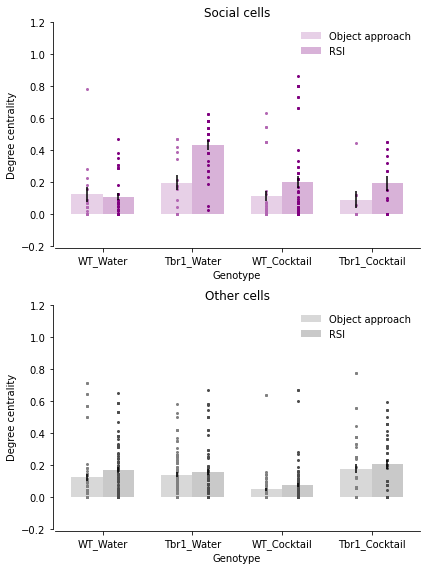

In [10]:
#draw bar plot
#draw social cells results
N = 4
ind = np.arange(N)    # the x locations for the groups
width = 0.35         # the width of the bars

plt.figure (figsize = (6,8))

ax1 = plt.subplot(2,1,1)
#OE
Water_OE_SC_means_DC = [WT_Water_OE_socialcells_mean_DC, Tbr1_Water_OE_socialcells_mean_DC,
                        WT_Cocktail_OE_socialcells_mean_DC, Tbr1_Cocktail_OE_socialcells_mean_DC]

Water_OE_SC_sem_DC = [WT_Water_OE_socialcells_sem_DC, Tbr1_Water_OE_socialcells_sem_DC,
                      WT_Cocktail_OE_socialcells_sem_DC, Tbr1_Cocktail_OE_socialcells_sem_DC]

ax1.bar(ind, Water_OE_SC_means_DC, width, yerr=Water_OE_SC_sem_DC, label='Object approach', color="#B266B2", alpha=0.3)

frames1= [WT_Water_OE_socialcells["Degree_centrality"], Tbr1_Water_OE_socialcells["Degree_centrality"], 
          WT_Cocktail_OE_socialcells["Degree_centrality"], Tbr1_Cocktail_OE_socialcells["Degree_centrality"]]
results1 = pd.concat(frames1)

ax1.scatter(([0]*len(WT_Water_OE_socialcells["Degree_centrality"])+
             [1]*len(Tbr1_Water_OE_socialcells["Degree_centrality"])+
             [2]*len(WT_Cocktail_OE_socialcells["Degree_centrality"])+
             [3]*len(Tbr1_Cocktail_OE_socialcells["Degree_centrality"])), 
            (results1), 
            s=4, c="#B266B2")

#RSI
Water_RSI_SC_means_DC = [WT_Water_RSI_socialcells_mean_DC, Tbr1_Water_RSI_socialcells_mean_DC,
                        WT_Cocktail_RSI_socialcells_mean_DC, Tbr1_Cocktail_RSI_socialcells_mean_DC]

Water_RSI_SC_sem_DC = [WT_Water_RSI_socialcells_sem_DC, Tbr1_Water_RSI_socialcells_sem_DC,
                      WT_Cocktail_RSI_socialcells_sem_DC, Tbr1_Cocktail_RSI_socialcells_sem_DC]

ax1.bar(ind + width, Water_RSI_SC_means_DC, width, yerr=Water_RSI_SC_sem_DC, label='RSI', color="purple", alpha=0.3)

frames2= [WT_Water_RSI_socialcells["Degree_centrality"], Tbr1_Water_RSI_socialcells["Degree_centrality"], 
          WT_Cocktail_RSI_socialcells["Degree_centrality"], Tbr1_Cocktail_RSI_socialcells["Degree_centrality"]]
results2 = pd.concat(frames2)

ax1.scatter(([width]*len(WT_Water_RSI_socialcells["Degree_centrality"])+
             [1+width]*len(Tbr1_Water_RSI_socialcells["Degree_centrality"])+
             [2+width]*len(WT_Cocktail_RSI_socialcells["Degree_centrality"])+
             [3+width]*len(Tbr1_Cocktail_RSI_socialcells["Degree_centrality"])), 
            (results2), 
            s=4, c="purple")

ax1.set_xticks([])
ax1.set(ylim=(-.2, 1.2))
plt.xticks(ind+width/2,['WT_Water','Tbr1_Water', 'WT_Cocktail','Tbr1_Cocktail'], rotation=0)

ax1.set_title("Social cells")
plt.xlabel ("Genotype")
plt.ylabel ("Degree centrality")

ax1.legend(frameon=False)


#####################################################################################
#draw other cells results
ax2 = plt.subplot(2,1,2)
#OE
Water_OE_SC_means_DC = [WT_Water_OE_othercells_mean_DC, Tbr1_Water_OE_othercells_mean_DC,
                        WT_Cocktail_OE_othercells_mean_DC, Tbr1_Cocktail_OE_othercells_mean_DC]

Water_OE_SC_sem_DC = [WT_Water_OE_othercells_sem_DC, Tbr1_Water_OE_othercells_sem_DC,
                      WT_Cocktail_OE_othercells_sem_DC, Tbr1_Cocktail_OE_othercells_sem_DC]

ax2.bar(ind, Water_OE_SC_means_DC, width, yerr=Water_OE_SC_sem_DC, label='Object approach', color="grey", alpha=0.3)

frames3= [WT_Water_OE_othercells["Degree_centrality"], Tbr1_Water_OE_othercells["Degree_centrality"], 
          WT_Cocktail_OE_othercells["Degree_centrality"], Tbr1_Cocktail_OE_othercells["Degree_centrality"]]
results3 = pd.concat(frames3)

ax2.scatter(([0]*len(WT_Water_OE_othercells["Degree_centrality"])+
             [1]*len(Tbr1_Water_OE_othercells["Degree_centrality"])+
             [2]*len(WT_Cocktail_OE_othercells["Degree_centrality"])+
             [3]*len(Tbr1_Cocktail_OE_othercells["Degree_centrality"])), 
            (results3), 
            s=4, c="grey")

#RSI
Water_RSI_SC_means_DC = [WT_Water_RSI_othercells_mean_DC, Tbr1_Water_RSI_othercells_mean_DC,
                        WT_Cocktail_RSI_othercells_mean_DC, Tbr1_Cocktail_RSI_othercells_mean_DC]

Water_RSI_SC_sem_DC = [WT_Water_RSI_othercells_sem_DC, Tbr1_Water_RSI_othercells_sem_DC,
                      WT_Cocktail_RSI_othercells_sem_DC, Tbr1_Cocktail_RSI_othercells_sem_DC]

ax2.bar(ind + width, Water_RSI_SC_means_DC, width, yerr=Water_RSI_SC_sem_DC, label='RSI', color="#4C4C4C", alpha=0.3)

frames4= [WT_Water_RSI_othercells["Degree_centrality"], Tbr1_Water_RSI_othercells["Degree_centrality"], 
          WT_Cocktail_RSI_othercells["Degree_centrality"], Tbr1_Cocktail_RSI_othercells["Degree_centrality"]]
results4 = pd.concat(frames4)

ax2.scatter(([width]*len(WT_Water_RSI_othercells["Degree_centrality"])+
             [1+width]*len(Tbr1_Water_RSI_othercells["Degree_centrality"])+
             [2+width]*len(WT_Cocktail_RSI_othercells["Degree_centrality"])+
             [3+width]*len(Tbr1_Cocktail_RSI_othercells["Degree_centrality"])), 
            (results4), 
            s=4, c="#4C4C4C")

ax2.set_xticks([])
ax2.set(ylim=(-.2, 1.2))
plt.xticks(ind+width/2,['WT_Water','Tbr1_Water', 'WT_Cocktail','Tbr1_Cocktail'], rotation=0)

ax2.set_title("Other cells")
plt.xlabel ("Genotype")
plt.ylabel ("Degree centrality")

ax2.legend(frameon=False)


plt.tight_layout()
sns.despine(offset=2)


plt.savefig(savefig + "Degree_centrality.pdf", transparent= True, bbox_inches="tight")
plt.savefig(savefig + "Degree_centrality.tif", transparent= True, bbox_inches="tight", dpi=720)

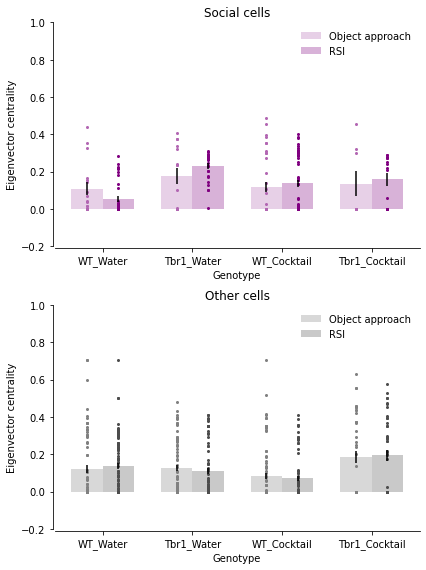

In [11]:
#draw bar plot
#draw social cells results
N = 4
ind = np.arange(N)    # the x locations for the groups
width = 0.35         # the width of the bars

plt.figure (figsize = (6,8))

ax1 = plt.subplot(2,1,1)
#OE
Water_OE_SC_means_EC = [WT_Water_OE_socialcells_mean_EC, Tbr1_Water_OE_socialcells_mean_EC,
                        WT_Cocktail_OE_socialcells_mean_EC, Tbr1_Cocktail_OE_socialcells_mean_EC]

Water_OE_SC_sem_EC = [WT_Water_OE_socialcells_sem_EC, Tbr1_Water_OE_socialcells_sem_EC,
                      WT_Cocktail_OE_socialcells_sem_EC, Tbr1_Cocktail_OE_socialcells_sem_EC]

ax1.bar(ind, Water_OE_SC_means_EC, width, yerr=Water_OE_SC_sem_EC, label='Object approach', color="#B266B2", alpha=0.3)

frames1= [WT_Water_OE_socialcells["Eigenvector_centrality"], Tbr1_Water_OE_socialcells["Eigenvector_centrality"], 
          WT_Cocktail_OE_socialcells["Eigenvector_centrality"], Tbr1_Cocktail_OE_socialcells["Eigenvector_centrality"]]
results1 = pd.concat(frames1)

ax1.scatter(([0]*len(WT_Water_OE_socialcells["Eigenvector_centrality"])+
             [1]*len(Tbr1_Water_OE_socialcells["Eigenvector_centrality"])+
             [2]*len(WT_Cocktail_OE_socialcells["Eigenvector_centrality"])+
             [3]*len(Tbr1_Cocktail_OE_socialcells["Eigenvector_centrality"])), 
            (results1), 
            s=4, c="#B266B2")

#RSI
Water_RSI_SC_means_EC = [WT_Water_RSI_socialcells_mean_EC, Tbr1_Water_RSI_socialcells_mean_EC,
                        WT_Cocktail_RSI_socialcells_mean_EC, Tbr1_Cocktail_RSI_socialcells_mean_EC]

Water_RSI_SC_sem_EC = [WT_Water_RSI_socialcells_sem_EC, Tbr1_Water_RSI_socialcells_sem_EC,
                      WT_Cocktail_RSI_socialcells_sem_EC, Tbr1_Cocktail_RSI_socialcells_sem_EC]

ax1.bar(ind + width, Water_RSI_SC_means_EC, width, yerr=Water_RSI_SC_sem_EC, label='RSI', color="purple", alpha=0.3)

frames2= [WT_Water_RSI_socialcells["Eigenvector_centrality"], Tbr1_Water_RSI_socialcells["Eigenvector_centrality"], 
          WT_Cocktail_RSI_socialcells["Eigenvector_centrality"], Tbr1_Cocktail_RSI_socialcells["Eigenvector_centrality"]]
results2 = pd.concat(frames2)

ax1.scatter(([width]*len(WT_Water_RSI_socialcells["Eigenvector_centrality"])+
             [1+width]*len(Tbr1_Water_RSI_socialcells["Eigenvector_centrality"])+
             [2+width]*len(WT_Cocktail_RSI_socialcells["Eigenvector_centrality"])+
             [3+width]*len(Tbr1_Cocktail_RSI_socialcells["Eigenvector_centrality"])), 
            (results2), 
            s=4, c="purple")

ax1.set_xticks([])
ax1.set(ylim=(-.2, 1))
plt.xticks(ind+width/2,['WT_Water','Tbr1_Water', 'WT_Cocktail','Tbr1_Cocktail'], rotation=0)

ax1.set_title("Social cells")
plt.xlabel ("Genotype")
plt.ylabel ("Eigenvector centrality")

ax1.legend(frameon=False)


#####################################################################################
#draw other cells results
ax2 = plt.subplot(2,1,2)
#OE
Water_OE_SC_means_EC = [WT_Water_OE_othercells_mean_EC, Tbr1_Water_OE_othercells_mean_EC,
                        WT_Cocktail_OE_othercells_mean_EC, Tbr1_Cocktail_OE_othercells_mean_EC]

Water_OE_SC_sem_EC = [WT_Water_OE_othercells_sem_EC, Tbr1_Water_OE_othercells_sem_EC,
                      WT_Cocktail_OE_othercells_sem_EC, Tbr1_Cocktail_OE_othercells_sem_EC]

ax2.bar(ind, Water_OE_SC_means_EC, width, yerr=Water_OE_SC_sem_EC, label='Object approach', color="grey", alpha=0.3)

frames3= [WT_Water_OE_othercells["Eigenvector_centrality"], Tbr1_Water_OE_othercells["Eigenvector_centrality"], 
          WT_Cocktail_OE_othercells["Eigenvector_centrality"], Tbr1_Cocktail_OE_othercells["Eigenvector_centrality"]]
results3 = pd.concat(frames3)

ax2.scatter(([0]*len(WT_Water_OE_othercells["Eigenvector_centrality"])+
             [1]*len(Tbr1_Water_OE_othercells["Eigenvector_centrality"])+
             [2]*len(WT_Cocktail_OE_othercells["Eigenvector_centrality"])+
             [3]*len(Tbr1_Cocktail_OE_othercells["Eigenvector_centrality"])), 
            (results3), 
            s=4, c="grey")

#RSI
Water_RSI_SC_means_EC = [WT_Water_RSI_othercells_mean_EC, Tbr1_Water_RSI_othercells_mean_EC,
                        WT_Cocktail_RSI_othercells_mean_EC, Tbr1_Cocktail_RSI_othercells_mean_EC]

Water_RSI_SC_sem_EC = [WT_Water_RSI_othercells_sem_EC, Tbr1_Water_RSI_othercells_sem_EC,
                      WT_Cocktail_RSI_othercells_sem_EC, Tbr1_Cocktail_RSI_othercells_sem_EC]

ax2.bar(ind + width, Water_RSI_SC_means_EC, width, yerr=Water_RSI_SC_sem_EC, label='RSI', color="#4C4C4C", alpha=0.3)

frames4= [WT_Water_RSI_othercells["Eigenvector_centrality"], Tbr1_Water_RSI_othercells["Eigenvector_centrality"], 
          WT_Cocktail_RSI_othercells["Eigenvector_centrality"], Tbr1_Cocktail_RSI_othercells["Eigenvector_centrality"]]
results4 = pd.concat(frames4)

ax2.scatter(([width]*len(WT_Water_RSI_othercells["Eigenvector_centrality"])+
             [1+width]*len(Tbr1_Water_RSI_othercells["Eigenvector_centrality"])+
             [2+width]*len(WT_Cocktail_RSI_othercells["Eigenvector_centrality"])+
             [3+width]*len(Tbr1_Cocktail_RSI_othercells["Eigenvector_centrality"])), 
            (results4), 
            s=4, c="#4C4C4C")

ax2.set_xticks([])
ax2.set(ylim=(-.2, 1))
plt.xticks(ind+width/2,['WT_Water','Tbr1_Water', 'WT_Cocktail','Tbr1_Cocktail'], rotation=0)

ax2.set_title("Other cells")
plt.xlabel ("Genotype")
plt.ylabel ("Eigenvector centrality")

ax2.legend(frameon=False)


plt.tight_layout()
sns.despine(offset=2)


plt.savefig(savefig + "Eigenvector_centrality.pdf", transparent= True, bbox_inches="tight")
plt.savefig(savefig + "Eigenvector_centrality.tif", transparent= True, bbox_inches="tight", dpi=720)

In [12]:
#save csv files
frames5= [WT_Water_OE_socialcells, Tbr1_Water_OE_socialcells, 
          WT_Cocktail_OE_socialcells, Tbr1_Cocktail_OE_socialcells,
          WT_Water_RSI_socialcells, Tbr1_Water_RSI_socialcells, 
          WT_Cocktail_RSI_socialcells, Tbr1_Cocktail_RSI_socialcells]

results5 = pd.concat(frames5)
print(results5)

pd.DataFrame(results5).to_csv(savecsv + "Socialcells_centrality.csv")



frames6= [WT_Water_OE_othercells, Tbr1_Water_OE_othercells, 
          WT_Cocktail_OE_othercells, Tbr1_Cocktail_OE_othercells,
          WT_Water_RSI_othercells, Tbr1_Water_RSI_othercells, 
          WT_Cocktail_RSI_othercells, Tbr1_Cocktail_RSI_othercells]
results6 = pd.concat(frames6)
print(results6)

pd.DataFrame(results6).to_csv(savecsv + "Othercells_centrality.csv")


     Degree_centrality  Eigenvector_centrality   Cell_type Genotype     Drink  \
8             0.000000            5.362076e-10  activation       WT     Water   
10            0.785714            3.515825e-01  activation       WT     Water   
12            0.285714            1.566426e-01  activation       WT     Water   
147           0.045455            1.675166e-01  activation       WT     Water   
148           0.000000           2.828679e-218  inhibition       WT     Water   
..                 ...                     ...         ...      ...       ...   
301           0.454545            2.760179e-01  activation     Tbr1  Cocktail   
302           0.363636            2.419027e-01  activation     Tbr1  Cocktail   
309           0.090909            5.631581e-02  activation     Tbr1  Cocktail   
313           0.000000            2.206341e-11  activation     Tbr1  Cocktail   
314           0.409091            2.202517e-01  activation     Tbr1  Cocktail   

    Behavior Number  
8    

In [65]:
WT_Water_RSI_socialcells_connection = WT_Subset_Centrality[(WT_Subset_Centrality["Genotype"]=="WT") & 
                                         (WT_Subset_Centrality["Drink"]=="Water") & 
                                         (WT_Subset_Centrality["Behavior"]=="RSI") & 
                                         (WT_Subset_Centrality["cell_type"].isin(["activation", "inhibition"]))]


WT_Water_RSI_othercells_connection = WT_Subset_Centrality[(WT_Subset_Centrality["Genotype"]=="WT") & 
                                        (WT_Subset_Centrality["Drink"]=="Water") & 
                                        (WT_Subset_Centrality["Behavior"]=="RSI") & 
                                        (WT_Subset_Centrality["cell_type"]=="other")]

Tbr1_Water_RSI_socialcells_connection = Tbr1_Subset_Centrality[(Tbr1_Subset_Centrality["Genotype"]=="Tbr1") & 
                                         (Tbr1_Subset_Centrality["Drink"]=="Water") & 
                                         (Tbr1_Subset_Centrality["Behavior"]=="RSI") & 
                                         (Tbr1_Subset_Centrality["cell_type"].isin(["activation", "inhibition"]))]


Tbr1_Water_RSI_othercells_connection = Tbr1_Subset_Centrality[(Tbr1_Subset_Centrality["Genotype"]=="Tbr1") & 
                                        (Tbr1_Subset_Centrality["Drink"]=="Water") & 
                                        (Tbr1_Subset_Centrality["Behavior"]=="RSI") & 
                                        (Tbr1_Subset_Centrality["cell_type"]=="other")]


WT_Cocktail_RSI_socialcells_connection = WT_Subset_Centrality[(WT_Subset_Centrality["Genotype"]=="WT") & 
                                         (WT_Subset_Centrality["Drink"]=="Cocktail") & 
                                         (WT_Subset_Centrality["Behavior"]=="RSI") & 
                                         (WT_Subset_Centrality["cell_type"].isin(["activation", "inhibition"]))]


WT_Cocktail_RSI_othercells_connection = WT_Subset_Centrality[(WT_Subset_Centrality["Genotype"]=="WT") & 
                                        (WT_Subset_Centrality["Drink"]=="Cocktail") & 
                                        (WT_Subset_Centrality["Behavior"]=="RSI") & 
                                        (WT_Subset_Centrality["cell_type"]=="other")]

Tbr1_Cocktail_RSI_socialcells_connection = Tbr1_Subset_Centrality[(Tbr1_Subset_Centrality["Genotype"]=="Tbr1") & 
                                         (Tbr1_Subset_Centrality["Drink"]=="Cocktail") & 
                                         (Tbr1_Subset_Centrality["Behavior"]=="RSI") & 
                                         (Tbr1_Subset_Centrality["cell_type"].isin(["activation", "inhibition"]))]


Tbr1_Cocktail_RSI_othercells_connection = Tbr1_Subset_Centrality[(Tbr1_Subset_Centrality["Genotype"]=="Tbr1") & 
                                        (Tbr1_Subset_Centrality["Drink"]=="Cocktail") & 
                                        (Tbr1_Subset_Centrality["Behavior"]=="RSI") & 
                                        (Tbr1_Subset_Centrality["cell_type"]=="other")]


#save csv files
frames7= [WT_Water_RSI_socialcells_connection, 
          Tbr1_Water_RSI_socialcells_connection,
          WT_Cocktail_RSI_socialcells_connection,
          Tbr1_Cocktail_RSI_socialcells_connection]

results7 = pd.concat(frames7)
print(results7)

pd.DataFrame(results7).to_csv(savecsv + "RSI_socialcells_subset_centrality.csv")


#save csv files
frames8= [WT_Water_RSI_othercells_connection, 
          Tbr1_Water_RSI_othercells_connection,
          WT_Cocktail_RSI_othercells_connection, 
          Tbr1_Cocktail_RSI_othercells_connection]

results8 = pd.concat(frames8)
print(results8)

pd.DataFrame(results8).to_csv(savecsv + "RSI_othercells_subset_centrality.csv")

      cell_type  social_connection_number  non_social_connection_number  \
23   activation                         0                             0   
26   activation                         0                             5   
27   activation                         1                             3   
30   inhibition                         0                             0   
71   inhibition                         0                             0   
..          ...                       ...                           ...   
301  activation                         0                             1   
302  activation                         3                             1   
309  activation                         0                             0   
313  activation                         0                             0   
314  activation                         5                             1   

     social_connection_centrality  non_social_connection_centrality Genotype  \
23                 

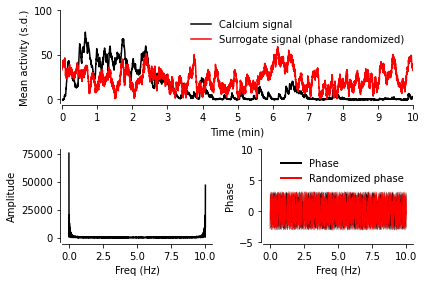

In [24]:
#Example of phase randomization
z_score_activity_example = pd.read_csv("Water_social_cell_analysis/NO.8/RSI/output_files/accrawt_z.csv", index_col=0, header=0).values

#Fourier transformation
np.random.seed(17)
trace_fft_example = fft(z_score_activity_example[0])    #FFT
amp_example = np.abs(trace_fft_example)    #Amplitude
sample_rate = 10
freq_example = np.fft.fftfreq(z_score_activity_example.size, d = 1 / sample_rate)      #Frequency
phase_example = np.angle(trace_fft_example)    #Phase

#Phase randomization
ph_noise_example = np.random.permutation(phase_example)
trace_random_example =  np.round(np.abs(ifft(amp_example * np.exp(1j*ph_noise_example))))    #https://github.com/JackEdTaylor/randphase


N = len(trace_fft_example)
n = np.arange(N)
T = N/sample_rate
freq_example2 = n/T

#draw
plt.figure (figsize = (6,4))
fig= plt.subplot (2,1,1)

plt.plot(z_score_activity_example[19], color="black", label="Calcium signal")
plt.plot(trace_random_example, color="red", label="Surrogate signal (phase randomized)")
plt.ylim([-5,100])

plt.xlim([0,6000])
plt.legend(frameon=False, loc= "upper right")
new_xticks = np.linspace(0, 6000, 11)
plt.xticks(new_xticks,[0,1,2,3,4,5,6,7,8,9,10], rotation=0)
plt.xlabel ("Time (min)")
plt.ylabel ("Mean activity (s.d.)")

fig= plt.subplot (2,2,3)
plt.plot(freq_example2, amp_example, color="black", label="Amplitude")
plt.xlabel("Freq (Hz)")
plt.ylabel("Amplitude")

fig= plt.subplot (2,2,4)
plt.plot(freq_example2, phase_example, color="black", label="Phase", linewidth=.1)
plt.plot(freq_example2, ph_noise_example, color="red", label="Randomized phase", linewidth=.1)
leg = plt.legend(frameon=False, loc= "upper right")
leg.get_lines()[0].set_linewidth(2)
leg.get_lines()[1].set_linewidth(2)
plt.ylim([-5, 10])
plt.xlabel("Freq (Hz)")
plt.ylabel("Phase")

plt.tight_layout()
sns.despine(offset=2)

plt.savefig("Results/Networkx/figure/Example of phase randomization.pdf", transparent= True, bbox_inches="tight")
plt.savefig("Results/Networkx/figure/Example of phase randomization.tif", transparent= True, bbox_inches="tight", dpi=720)

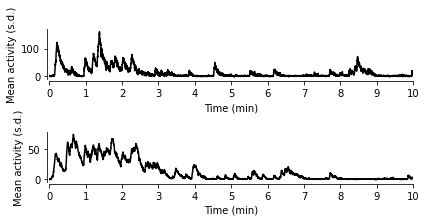

In [45]:
#Example of two calcium signals
z_score_activity_example = pd.read_csv("Water_social_cell_analysis/NO.8/RSI/output_files/accrawt_z.csv", index_col=0, header=0).values

#draw
plt.figure (figsize = (6,3))
fig= plt.subplot (2,1,1)

plt.plot(z_score_activity_example[0], color="black", label="Calcium signal")
plt.xlim([0,6000])
# plt.legend(frameon=False, loc= "upper right")
new_xticks = np.linspace(0, 6000, 11)
plt.xticks(new_xticks,[0,1,2,3,4,5,6,7,8,9,10], rotation=0)
plt.xlabel ("Time (min)")
plt.ylabel ("Mean activity (s.d.)")

fig= plt.subplot (2,1,2)

plt.plot(z_score_activity_example[19], color="black", label="Calcium signal")
plt.xlim([0,6000])
# plt.legend(frameon=False, loc= "upper right")
new_xticks = np.linspace(0, 6000, 11)
plt.xticks(new_xticks,[0,1,2,3,4,5,6,7,8,9,10], rotation=0)
plt.xlabel ("Time (min)")
plt.ylabel ("Mean activity (s.d.)")

plt.tight_layout()
sns.despine(offset=2)

plt.savefig("Results/Networkx/figure/Example of calcium signals.pdf", transparent= True, bbox_inches="tight")
plt.savefig("Results/Networkx/figure/Example of calcium signals.tif", transparent= True, bbox_inches="tight", dpi=720)

100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:13<00:00, 758.09it/s]


<Figure size 432x216 with 0 Axes>

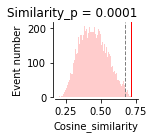

In [30]:
#Example of phase randomization
z_score_activity_example = pd.read_csv("Water_social_cell_analysis/NO.8/RSI/output_files/accrawt_z.csv", index_col=0, header=0).values

#draw
plt.figure (figsize = (6,3))

# plt.plot(z_score_activity_example[0], color="black", label="Calcium signal")

# plt.plot(z_score_activity_example[19], color="black", label="Calcium signal")


#generate cosine similarity of shuffled social interaction and calcium signal
np.random.seed(17)
shuffletimes = 10000   #shuffled 10000times


cs_shuffle_ind = []
cs_p1 = 0


rowr1 = z_score_activity_example[0,:]
rowr2= z_score_activity_example[19,:]

#Cosine  similarity (Raw data)
cs_raw = cosine_similarity([rowr1], [rowr2]).tolist()
cs_raw2 = list(chain(*cs_raw))

for a in tqdm(range (shuffletimes)):

    #Fourier transformation
    trace_fft = fft(rowr2)    #FFT
    amp = np.abs(trace_fft)    #Amplitude
    phase = np.angle(trace_fft)    #Phase
#             sample_rate = 10
#             freq = np.fft.fftfreq(z_score_activity.size, d = 1 / sample_rate)      #Frequency

    #Phase randomization
    ph_noise = np.random.permutation(phase)
#             trace_random =  ifft(amp * np.exp(1j * ph_noise))
    trace_random =  np.round(np.abs(ifft(amp * np.exp(1j*ph_noise))))    #https://github.com/JackEdTaylor/randphase

    #Cosine  similarity (Shuffled data)
    cs_shuffle = cosine_similarity([rowr1], [trace_random]).tolist()
    cs_shuffle2 = list(chain(*cs_shuffle))

    for k in cs_shuffle2:
        cs_shuffle_ind.append(k)

        if k >= cs_raw2[0]:
            cs_p1 += 1

cs_p =  cs_p1/shuffletimes
cs_p_cell.append(cs_p)



#plot random shuffled_sum distribution and true distribution
plt.figure (figsize = (2,2))
plt.hist(cs_shuffle_ind, density= False, bins= int(np.sqrt(len(np.transpose(cs_shuffle_ind)))), color= "#FFCCCC", edgecolor='none')
plt.axvline(x= cs_raw2, color='red', linewidth= 1)
plt.axvline(x= np.percentile(cs_shuffle_ind, 99.17), color='gray', linewidth= 1, linestyle= '--')
# plt.axvline(x= np.percentile(shuffled_cs[roci], 5), color='gray', linewidth= 1, linestyle= '--')
plt.xlabel ("Cosine_similarity")
plt.ylabel ("Event number")
plt.title("Similarity_p = "+ str(cs_p), loc= "right")

plt.tight_layout()
sns.despine(offset=2)

plt.savefig("Results/Networkx/figure/Example of null distribution.pdf", transparent= True, bbox_inches="tight")
plt.savefig("Results/Networkx/figure/Example of null distribution.tif", transparent= True, bbox_inches="tight", dpi=720)

In [4]:
def Networkx_only_function(nm, dk, bh, savecsv, savefig):    
    #read txt file
    Parsing_cells = pd.read_table("parsing_cell_type_to_links_"+ nm +".txt", index_col=0)
    #read Multi-session registration file
    MSR = pd.read_csv("Multi-session_registration_"+ nm +".csv", index_col=0, header=0)


    #read Cosine similarity and P_value files
    CS_table = pd.read_csv(savecsv + "cosine_similarity.csv", index_col=0)
    CS_table.index = CS_table.index+1
    CS_table.columns = CS_table.index

    CS_p_table = pd.read_csv(savecsv + "cosine_similarity_p.csv", index_col=0)
    CS_p_table.index = CS_p_table.index+1
    CS_p_table.columns = CS_p_table.index


    #draw heatmap and networks
    plt.figure(figsize=(4,4))

    G = nx.Graph()
    colors = []
    cell_type = []

    if dk =="Water":
        col = "Water_RSI"
        
    elif dk =="Cocktail":
        col = "Cocktail_RSI"
    
    for i in CS_table.index:
        G.add_node(i)

        #define color
        for k in range(len(MSR)):
            if MSR.loc[k][dk + "_" + bh] == i:

                if Parsing_cells.loc[k][col] == "activation":
                    colors.append("#ff6666")  #ff9393
                    cell_type.append("activation")
                elif Parsing_cells.loc[k][col] == "inhibition":
                    colors.append("#6666ff")  #ADD8E6
                    cell_type.append("inhibition")
                else:
                    colors.append("#999999")  #D3D3D3
                    cell_type.append("other")

        for j in CS_table.columns:
            if i != j:
                if CS_p_table.loc[i][j] <= 0.0083:
                    w = CS_table.loc[i][j]
                    G.add_edge(i,j, weight= w)
        #             G.add_edge(i,j, weight= round(w,1))

    pos = nx.spring_layout(G, scale=1, seed=17)
    # weight= nx.get_edge_attributes(G, "weight")

    nx.draw_networkx(G, pos, with_labels=False, font_weight='bold', 
                     node_size=40, font_size=5, alpha=1, node_color=colors,
                     edge_color='black')
#     plt.title("Networks")
    plt.box(False)
    
    plt.tight_layout()

    plt.savefig(savefig + "Networkx_2.pdf", transparent=True, bbox_inches="tight")
    plt.savefig(savefig + "Networkx_2.tif", transparent=True, bbox_inches="tight", dpi=720)

<ipython-input-4-2a31b2edd6bd>:19: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(figsize=(4,4))


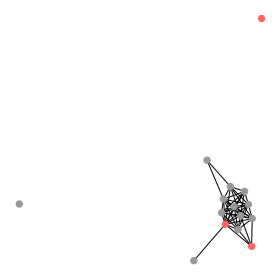

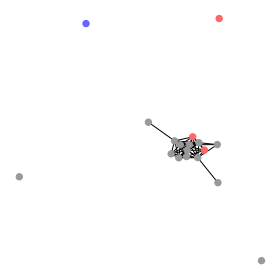

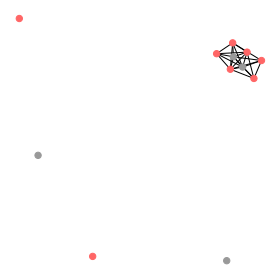

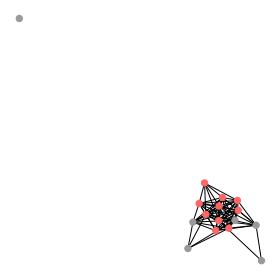

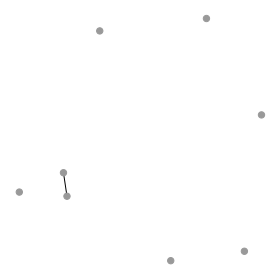

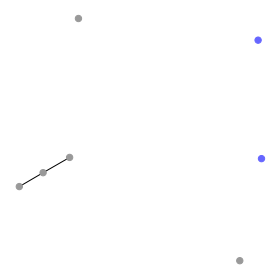

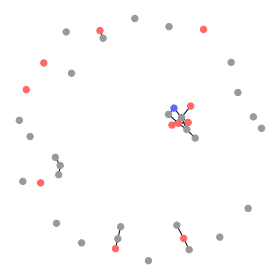

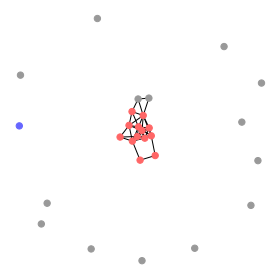

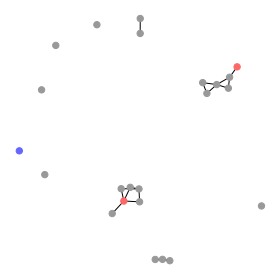

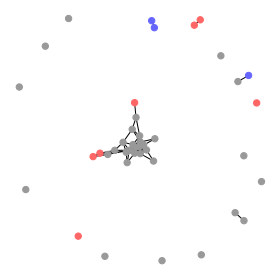

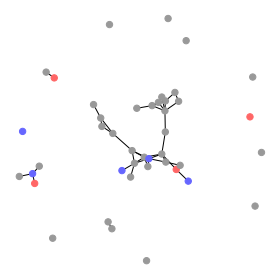

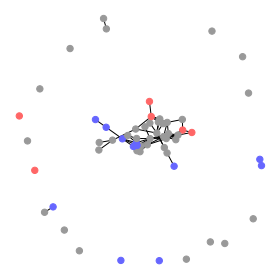

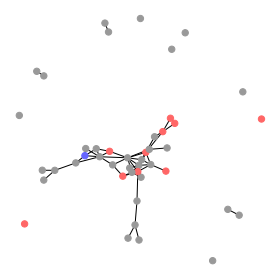

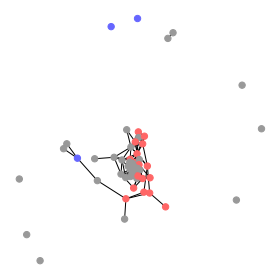

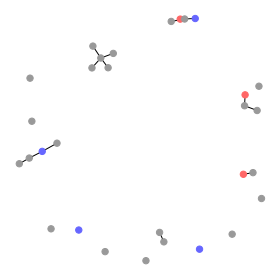

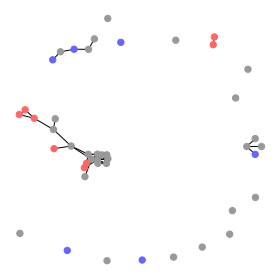

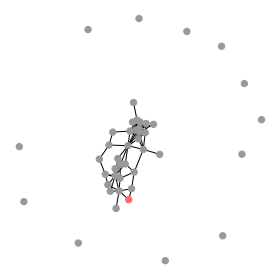

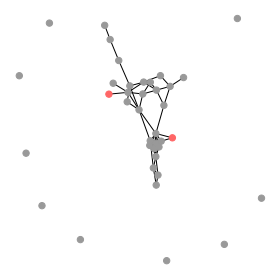

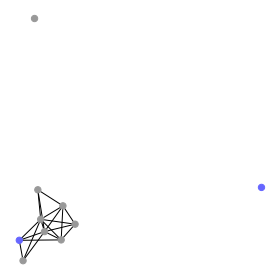

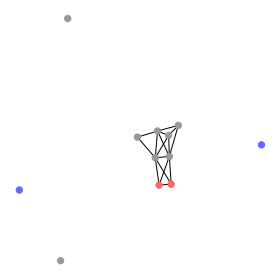

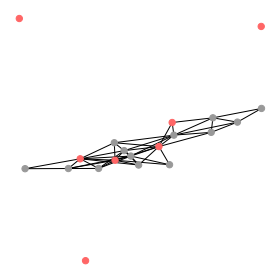

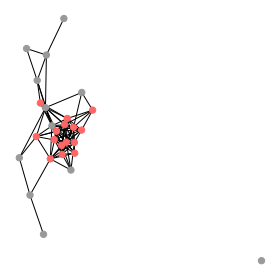

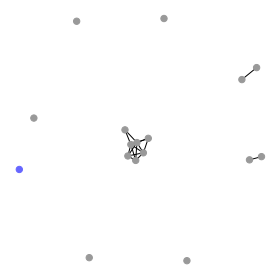

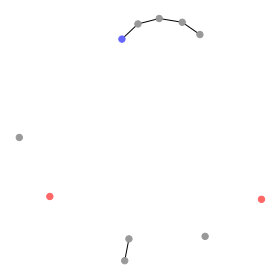

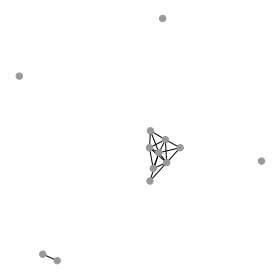

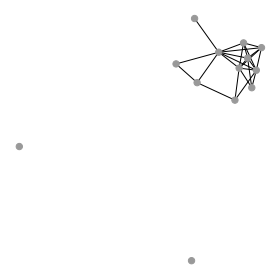

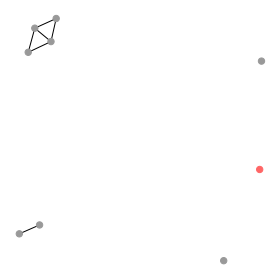

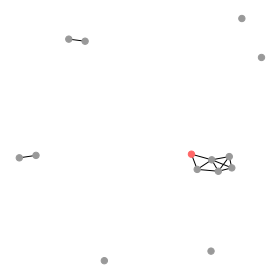

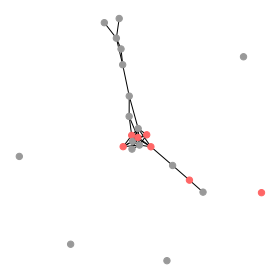

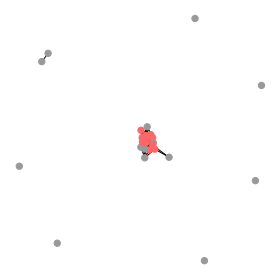

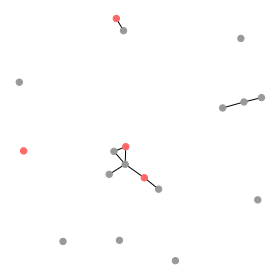

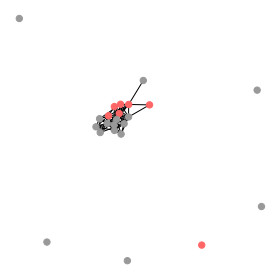

In [5]:
#Example of Networks (WT:NO.8, Tbr1:NO.20)
#Genotype of each number
WT_Number = ["NO.1", "NO.2", "NO.8", "NO.15"]
Tbr1_Number = ["NO.3", "NO.13", "NO.16", "NO.20"]

#Treatment and behavior
drinks = ["Water", "Cocktail"]
behaviors = ["OE", "RSI"]

for nm in WT_Number:
    
    #read txt file
    Parsing_cells = pd.read_table("parsing_cell_type_to_links_"+ nm +".txt")
    #read Multi-session registration file
    MSR = pd.read_csv("Multi-session_registration_"+ nm +".csv", index_col=0, header=0)
    
    for dk in drinks:
        for bh in behaviors:
        
            savecsv1 = savecsv + "WT/" + nm + "/" + dk + "/" + bh + "/"
            savefig1 = savefig + "WT/" + nm + "/" + dk + "/" + bh + "/"
            
            Networkx_only_function(nm, dk, bh, savecsv1, savefig1)

for nm in Tbr1_Number:
    
    #read txt file
    Parsing_cells = pd.read_table("parsing_cell_type_to_links_"+ nm +".txt")
    #read Multi-session registration file
    MSR = pd.read_csv("Multi-session_registration_"+ nm +".csv", index_col=0, header=0)
    
    for dk in drinks:
        for bh in behaviors:
        
            savecsv1 = savecsv + "Tbr1/" + nm + "/" + dk + "/" + bh + "/"
            savefig1 = savefig + "Tbr1/" + nm + "/" + dk + "/" + bh + "/"
            
            Networkx_only_function(nm, dk, bh, savecsv1, savefig1)